# 🏠 Singapore HDB Resale Price Analysis & Prediction
## Notebook 5 — Finding Overpriced & Underpriced Flats

A price model isn't just for prediction — it's a **valuation engine**. If the model says a flat is worth
S$600k and it sold for S$520k, the buyer likely got a deal; S$700k and someone overpaid (or the flat has
qualities invisible to the data — renovation, view, urgency).

### Methodology (leakage-free)
Scoring a transaction with a model that *trained on that same transaction* would make every price look
"fair". So:

1. Train the tuned LightGBM **only on data older than the most recent 12 months**
2. Predict the most recent 12 months **out-of-sample** → `fair value`
3. **Valuation gap** = (actual − predicted) / predicted
4. Flag |gap| > 10% as over/under-priced (≈ the model's honest uncertainty band from Notebook 4)

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook lives in notebooks/ — project root is one level up. The fallback lets
# the same code run whether the kernel starts in notebooks/ or the repo root.
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
FIGURES = ROOT / "reports" / "figures"      # charts are saved here for the README/report
FIGURES.mkdir(parents=True, exist_ok=True)

# Consistent plot styling across the whole notebook.
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 5)
pd.set_option("display.max_columns", 40)

In [2]:
import joblib
import lightgbm as lgb

from sg_hdb_price_analysis.models.train import prepare_xy

# Reuse the tuned hyperparameters found in Notebook 4 (stored in the artifact).
df = pd.read_parquet(ROOT / "data" / "interim" / "features_full.parquet")
artifact = joblib.load(ROOT / "models" / "lgbm_model.pkl")
best_params = {**artifact["best_params"], "n_estimators": 3000, "bagging_freq": 1,
               "random_state": 42, "n_jobs": -1, "verbosity": -1}

X, y, cat_features, features, medians = prepare_xy(df)
# Keep human-readable columns alongside X so we can label each scored flat.
meta = df.loc[X.index, ["month", "town", "flat_type", "block", "street_name",
                        "storey_range", "floor_area_sqm", "lat", "lon"]]

# Leakage guard: train only on data OLDER than the last 12 months, then score the
# recent 12 months out-of-sample so "fair value" is never fit on the row itself.
cutoff = meta["month"].max() - pd.DateOffset(months=12)
train_mask = meta["month"] <= cutoff
print(f"Valuation model trains on {train_mask.sum():,} txns (≤ {cutoff:%Y-%m}), "
      f"scores {(~train_mask).sum():,} recent txns out-of-sample")

Valuation model trains on 210,108 txns (≤ 2025-06), scores 22,506 recent txns out-of-sample


In [3]:
%%time
# Fit on the older data, predict fair value for the recent (held-out) transactions.
X_enc = X.copy()
X_enc[cat_features] = artifact["encoder"].transform(X[cat_features])

val_model = lgb.LGBMRegressor(**best_params)
val_model.fit(X_enc[train_mask], y[train_mask])

recent = meta[~train_mask].copy()
recent["actual"] = y[~train_mask]
recent["predicted"] = val_model.predict(X_enc[~train_mask])
recent["gap"] = recent["actual"] - recent["predicted"]                 # S$ over/under fair value
recent["gap_pct"] = recent["gap"] / recent["predicted"] * 100          # as a % of fair value
print(f"Median |gap|: {recent['gap_pct'].abs().median():.1f}%")

Median |gap|: 2.9%
CPU times: user 1min 9s, sys: 3min 32s, total: 4min 42s
Wall time: 1min 29s


## 1. Distribution of valuation gaps

Most transactions should cluster near 0% (the market is mostly efficient); the tails are the interesting part.

Underpriced: 522 (2.3%)   Fair: 21,352 (94.9%)   Overpriced: 632 (2.8%)


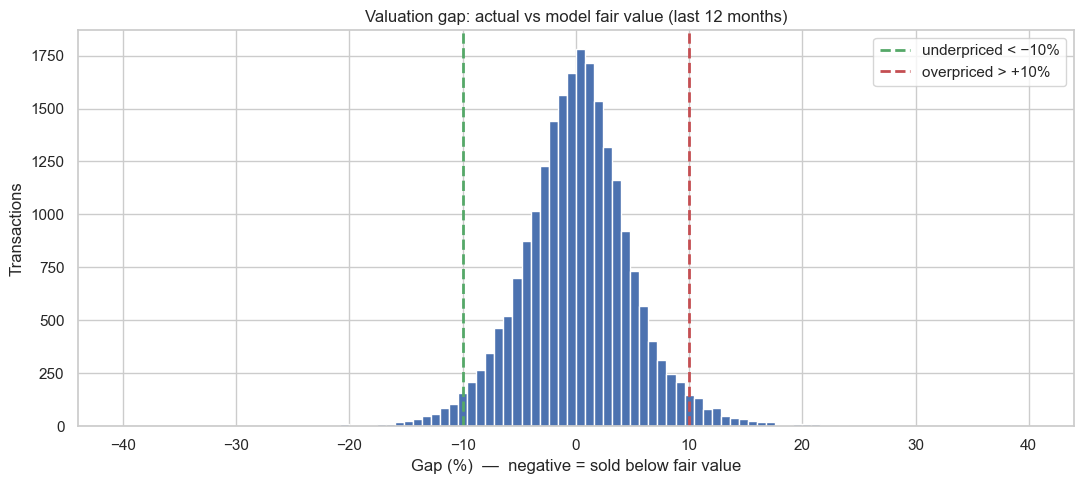

In [4]:
THRESH = 10  # ±10% band ≈ the model's honest uncertainty (from Notebook 4)

# Distribution of valuation gaps — most cluster near 0% (efficient market);
# the tails beyond ±THRESH are the bargains and overpayments.
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(recent["gap_pct"].clip(-40, 40), bins=100, color="#4C72B0")
ax.axvline(-THRESH, color="#55A868", ls="--", lw=2, label=f"underpriced < −{THRESH}%")
ax.axvline(THRESH, color="#C44E52", ls="--", lw=2, label=f"overpriced > +{THRESH}%")
ax.set(title="Valuation gap: actual vs model fair value (last 12 months)",
       xlabel="Gap (%)  —  negative = sold below fair value", ylabel="Transactions")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "valuation_gaps.png", dpi=150, bbox_inches="tight")

under = (recent["gap_pct"] < -THRESH).sum()
over = (recent["gap_pct"] > THRESH).sum()
fair = len(recent) - under - over
print(f"Underpriced: {under:,} ({under/len(recent):.1%})   "
      f"Fair: {fair:,} ({fair/len(recent):.1%})   "
      f"Overpriced: {over:,} ({over/len(recent):.1%})")

## 2. The biggest bargains and overpayments

In [5]:
# Helper to pretty-print a slice of deals (format date, round prices).
show_cols = ["month", "town", "block", "street_name", "flat_type", "storey_range",
             "floor_area_sqm", "actual", "predicted", "gap_pct"]

def fmt(d):
    d = d[show_cols].copy()
    d["month"] = d["month"].dt.strftime("%Y-%m")
    d[["actual", "predicted"]] = d[["actual", "predicted"]].round(0)
    d["gap_pct"] = d["gap_pct"].round(1)
    return d.reset_index(drop=True)

# Biggest bargains: most negative gaps (sold furthest below fair value).
print("🟢 Top 10 UNDERPRICED (sold furthest below fair value):")
fmt(recent.nsmallest(10, "gap_pct"))

🟢 Top 10 UNDERPRICED (sold furthest below fair value):


,month,town,block,street_name,flat_type,storey_range,floor_area_sqm,actual,predicted,gap_pct
0,2025-12,WOODLANDS,616,WOODLANDS AVE 4,4 ROOM,04 TO 06,102.0,318000.0,551239.0,-42.3
1,2025-11,TAMPINES,726,TAMPINES ST 71,5 ROOM,07 TO 09,125.0,518000.0,809815.0,-36.0
2,2026-03,JURONG EAST,20,TEBAN GDNS RD,3 ROOM,01 TO 03,72.0,300000.0,459505.0,-34.7
3,2025-11,TOA PAYOH,62,LOR 4 TOA PAYOH,4 ROOM,04 TO 06,100.0,590000.0,821447.0,-28.2
4,2026-05,TOA PAYOH,107,POTONG PASIR AVE 1,3 ROOM,13 TO 15,74.0,420000.0,570511.0,-26.4
5,2025-11,BUKIT MERAH,8,JLN BT HO SWEE,3 ROOM,07 TO 09,56.0,280000.0,372616.0,-24.9
6,2026-05,YISHUN,722,YISHUN ST 71,5 ROOM,01 TO 03,131.0,510888.0,676370.0,-24.5
7,2025-12,TOA PAYOH,205,TOA PAYOH NTH,3 ROOM,04 TO 06,65.0,300000.0,396904.0,-24.4
8,2026-01,ANG MO KIO,131,ANG MO KIO AVE 3,4 ROOM,07 TO 09,98.0,443000.0,583376.0,-24.1
9,2026-03,BISHAN,231,BISHAN ST 23,EXECUTIVE,01 TO 03,146.0,935000.0,1221733.0,-23.5


In [6]:
# Biggest overpayments: most positive gaps (sold furthest above fair value).
print("🔴 Top 10 OVERPRICED (sold furthest above fair value):")
fmt(recent.nlargest(10, "gap_pct"))

🔴 Top 10 OVERPRICED (sold furthest above fair value):


,month,town,block,street_name,flat_type,storey_range,floor_area_sqm,actual,predicted,gap_pct
0,2026-02,PUNGGOL,306D,PUNGGOL DR,5 ROOM,16 TO 18,147.0,1470000.0,1043660.0,40.9
1,2026-05,BUKIT MERAH,50,MOH GUAN TER,4 ROOM,01 TO 03,150.0,1530000.0,1135456.0,34.7
2,2026-02,PUNGGOL,421A,NORTHSHORE DR,2 ROOM,07 TO 09,47.0,520000.0,387734.0,34.1
3,2026-05,QUEENSTOWN,41,HOLLAND DR,3 ROOM,04 TO 06,59.0,475888.0,368183.0,29.3
4,2026-02,TOA PAYOH,154,LOR 2 TOA PAYOH,5 ROOM,13 TO 15,124.0,1218000.0,942678.0,29.2
5,2026-05,BEDOK,153C,BEDOK STH RD,5 ROOM,04 TO 06,113.0,1380000.0,1068617.0,29.1
6,2025-11,PASIR RIS,603,ELIAS RD,EXECUTIVE,01 TO 03,149.0,1250000.0,971765.0,28.6
7,2026-03,TOA PAYOH,140,POTONG PASIR AVE 3,3 ROOM,07 TO 09,74.0,625888.0,488774.0,28.1
8,2026-04,BEDOK,154B,BEDOK STH RD,4 ROOM,16 TO 18,93.0,1170000.0,920007.0,27.2
9,2026-05,BEDOK,153B,BEDOK STH RD,5 ROOM,16 TO 18,113.0,1400000.0,1103007.0,26.9


> ⚠️ **Interpretation caveat** — an extreme gap is *either* a genuine mispricing *or* something the model
> can't see: full renovations, corner units, unblocked views, urgent sales, or family transfers below
> market. The model narrows the haystack; a human checks the needle.

## 3. Where are deals found? Gap structure by town

,n,pct_under,pct_over,median_gap
town,,,,
BEDOK,1108,3.88,1.99,-1.02
JURONG EAST,449,3.12,0.45,-0.75
PASIR RIS,638,1.72,0.94,-0.40
CHOA CHU KANG,932,1.82,0.86,-0.36
WOODLANDS,1633,1.96,0.92,-0.35
BUKIT PANJANG,751,2.40,2.00,-0.30
YISHUN,1459,2.06,0.82,-0.23
GEYLANG,628,3.18,4.78,-0.21


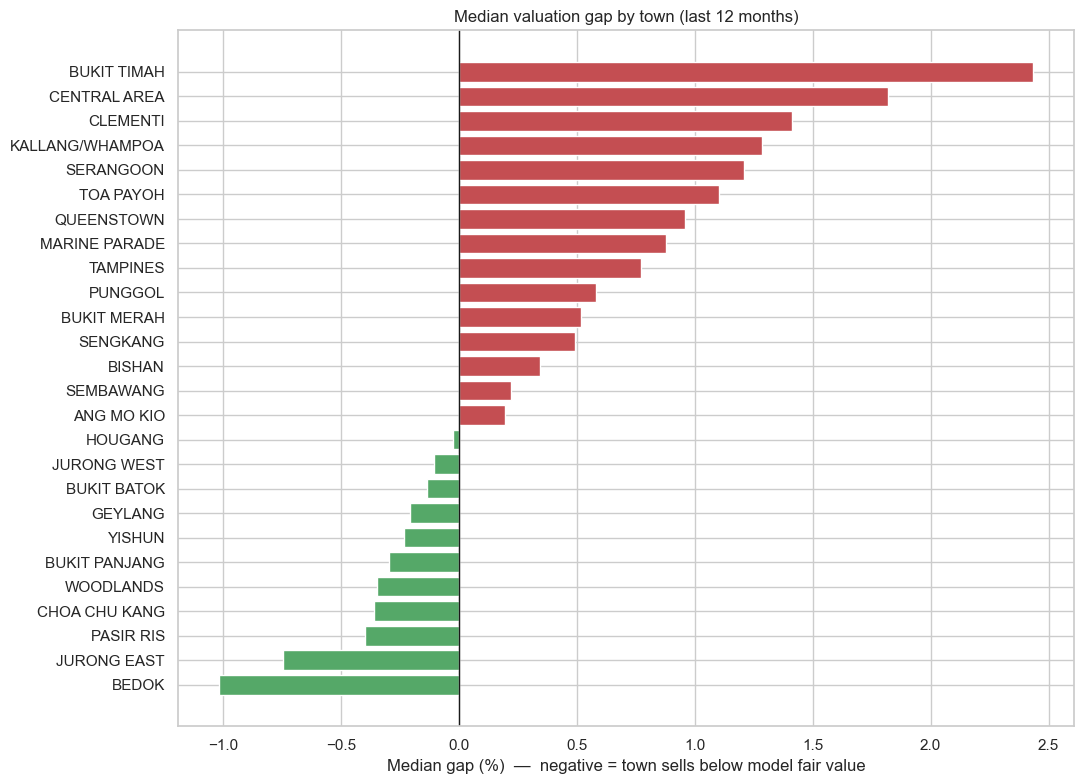

In [7]:
# Where are the deals? Aggregate gap statistics per town. Small medians here are
# reassuring — it means the model has no large location bias, so deals are
# scattered individual transactions, not whole mispriced towns.
by_town = recent.groupby("town").agg(
    n=("gap_pct", "size"),
    pct_under=("gap_pct", lambda s: (s < -THRESH).mean() * 100),
    pct_over=("gap_pct", lambda s: (s > THRESH).mean() * 100),
    median_gap=("gap_pct", "median"),
).sort_values("median_gap")

fig, ax = plt.subplots(figsize=(11, 8))
colors = np.where(by_town["median_gap"] < 0, "#55A868", "#C44E52")
ax.barh(by_town.index, by_town["median_gap"], color=colors)
ax.axvline(0, color="k", lw=1)
ax.set(title="Median valuation gap by town (last 12 months)",
       xlabel="Median gap (%)  —  negative = town sells below model fair value")
plt.tight_layout()
by_town.round(2).head(8)

Town-level median gaps are small (within a few %) — reassuring: the model has no large systematic
location bias, and "deals" are scattered individual transactions rather than entire mispriced towns.

## 4. Deal map

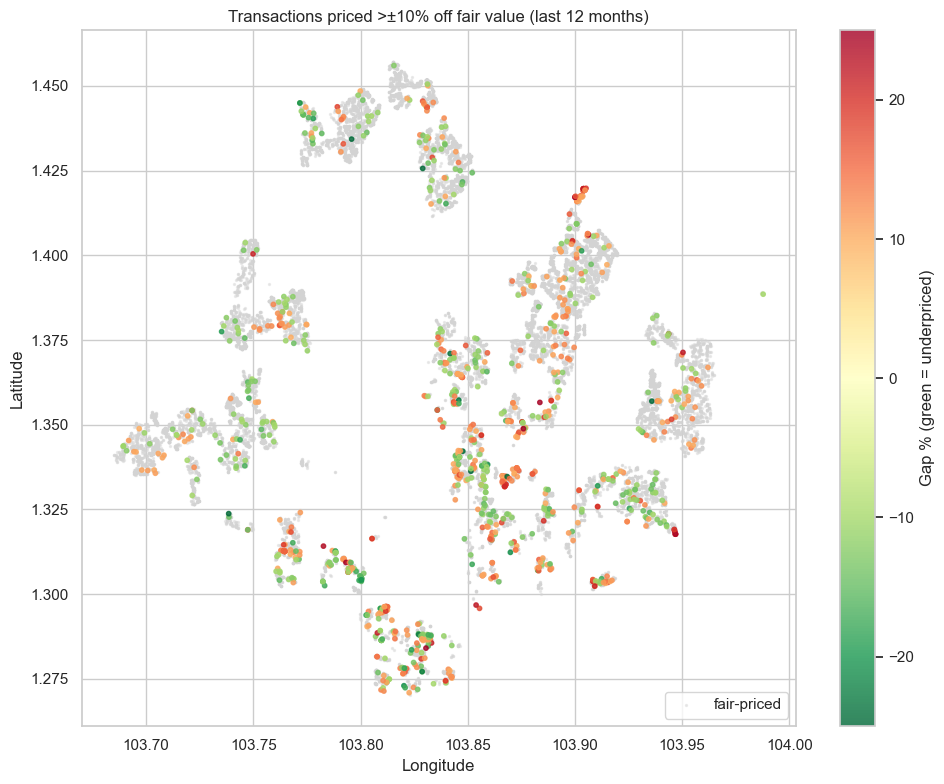

In [8]:
# Map the flagged deals: grey = fair-priced, coloured = beyond ±THRESH
# (green underpriced, red overpriced).
geo = recent.dropna(subset=["lat"])
flagged = geo[geo["gap_pct"].abs() > THRESH]

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(geo["lon"], geo["lat"], s=2, color="lightgrey", alpha=0.4, label="fair-priced")
sc = ax.scatter(flagged["lon"], flagged["lat"], c=flagged["gap_pct"], cmap="RdYlGn_r",
                vmin=-25, vmax=25, s=10, alpha=0.8)
ax.set(title=f"Transactions priced >±{THRESH}% off fair value (last 12 months)",
       xlabel="Longitude", ylabel="Latitude")
plt.colorbar(sc, label="Gap % (green = underpriced)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES / "deal_map.png", dpi=150, bbox_inches="tight")

## 5. Export for the dashboard

The Streamlit **Deal Finder** page reads this CSV, letting users filter by town / flat type / gap threshold
and browse deals on an interactive map.

In [9]:
# Export every scored transaction for the Streamlit / web-app Deal Finder pages.
out_cols = ["month", "town", "block", "street_name", "flat_type", "storey_range",
            "floor_area_sqm", "lat", "lon", "actual", "predicted", "gap", "gap_pct"]
valuations = recent[out_cols].copy()
valuations["predicted"] = valuations["predicted"].round(0)
valuations["gap"] = valuations["gap"].round(0)
valuations["gap_pct"] = valuations["gap_pct"].round(2)
out = ROOT / "data" / "processed" / "valuations.csv"
valuations.to_csv(out, index=False)
print(f"Saved {len(valuations):,} scored transactions → {out.relative_to(ROOT)}")

Saved 22,506 scored transactions → data/processed/valuations.csv


## 6. Project wrap-up

| Deliverable | Where |
|-------------|-------|
| Reproducible data pipeline (API → features) | `sg_hdb_price_analysis/` package, `make all` |
| EDA with documented findings | Notebooks 1–3 |
| Tuned LightGBM model (RMSE/MAE/R² in NB4) | `models/lgbm_model.pkl` |
| Valuation engine + deal detection | This notebook → `data/processed/valuations.csv` |
| Interactive dashboard (trends, maps, prediction, deal finder) | `streamlit run app/dashboard.py` |

**Possible extensions:** quantile regression for prediction intervals, SHAP values for per-flat
explanations, resale *listing* (asking-price) data to flag deals before they transact, and
auto-retraining via GitHub Actions when data.gov.sg publishes new months.